<a href="https://colab.research.google.com/github/hankymun/ex_2.11-2.14/blob/main/flower_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 176, 176, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 88, 88, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 88, 88, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 495616)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    63,438,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,459,013 (242.08 MB)

 Trainable params: 63,459,013 (242.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 502s 5s/step - accuracy: 0.3692 - loss: 3.1486 - val_accuracy: 0.4877 - val_loss: 1.3541
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 502s 5s/step - accuracy: 0.4864 - loss: 1.2953 - val_accuracy: 0.5736 - val_loss: 1.1324
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 488s 5s/step - accuracy: 0.5695 - loss: 1.1082 - val_accuracy: 0.5518 - val_loss: 1.1156
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 497s 5s/step - accuracy: 0.6689 - loss: 0.8786 - val_accuracy: 0.6117 - val_loss: 0.9906
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 489s 5s/step - accuracy: 0.7626 - loss: 0.6644 - val_accuracy: 0.6567 - val_loss: 0.9686
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 484s 5s/step - accuracy: 0.8389 - loss: 0.4503 - val_accuracy: 0.6199 - val_loss: 1.0525
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 503s 5s/step - accuracy: 0.8948 - loss: 0.3152 - val_accuracy: 0.6022 - val_loss: 1.2202
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 485s 5s/step - accuracy: 0.9254 - loss: 0.2137 - val_accuracy: 0.5777 - v

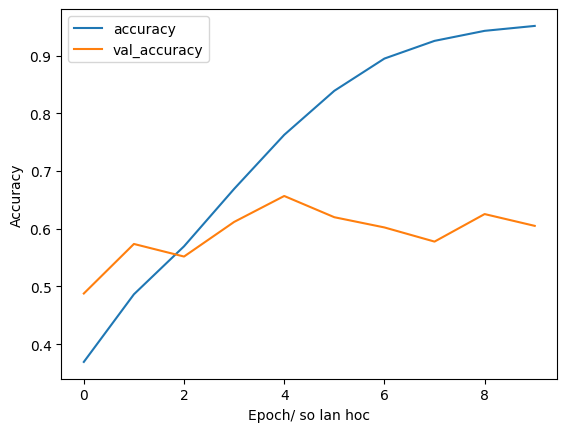

In [2]:
# =====================================================================
# BƯỚC 1: IMPORT CÁC THƯ VIỆN CẦN THIẾT VÀ TẢI BỘ DỮ LIỆU HOA (TF_FLOWERS)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pathlib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling

# Tải dữ liệu ảnh hoa từ kho lưu trữ của TensorFlow
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

# Fix: Adjust data_dir to point to the actual directory containing class subfolders
# This is a common issue where get_file untars to a directory that contains another directory of the same name,
# which then contains the class folders.
data_dir = data_dir / 'flower_photos'

# =====================================================================
# BƯỚC 2: CẤU HÌNH VÀ TIỀN XỬ LÝ DỮ LIỆU (TƯƠNG TỰ FILE GỐC)
# =====================================================================
batch_size = 32
img_height = 180
img_width = 180
num_classes = 5  # Tập dữ liệu hoa có 5 lớp đầu ra thay vì 10 lớp như MNIST

# Tải tập huấn luyện (Train set) - Chia tỉ lệ 80% cho Train
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'  # Đưa nhãn về dạng One-hot tương tự to_categorical trong file gốc
)

# Tải tập kiểm thử/kiểm định (Validation set) - Lấy 20% còn lại
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

# Tối ưu hóa hiệu năng đọc/ghi dữ liệu của Colab bằng Cache và Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================================================================
# BƯỚC 3: XÂY DỰNG MÔ HÌNH CNN (Kiến trúc tương đồng với CNN.ipynb)
# =====================================================================
model = Sequential()

# Thêm lớp chuẩn hóa dữ liệu đầu vào (chia cho 255.0 tương tự x_train / 255. ở file cũ)
model.add(Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# Các lớp Convolutional và MaxPooling giữ nguyên cấu trúc phân tầng của bạn
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Phẳng hóa ma trận và đưa qua các lớp Dense (Ẩn)
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))  # Thay đổi số lượng nút đầu ra thành 5

# Hiển thị bảng tổng quát cấu trúc mạng CNN
model.summary()

# =====================================================================
# BƯỚC 4: BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH
# =====================================================================
# Sử dụng cùng bộ tối ưu rmsprop và hàm loss categorical_crossentropy như file gốc
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

# =====================================================================
# BƯỚC 5: ĐÁNH GIÁ VÀ VẼ ĐỒ THỊ KẾT QUẢ ĐỘ CHÍNH XÁ (ACCURACY)
# =====================================================================
test_loss, test_acc = model.evaluate(val_ds)
print('\nĐộ chính xác trên tập kiểm tra (Test accuracy):', test_acc)

# Vẽ đồ thị trực quan quá trình học tập của mô hình giống như file CNN.ipynb
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch/ so lan hoc')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [4]:
import numpy as np
from keras.utils import load_img, img_to_array
# tai anh
img = load_img('/content/1000011271 (1).jpg', target_size=(180, 180)) # Changed target_size to 180, 180
img = img_to_array(img)
#chuyen thanh mang
# Removed redundant img = img_to_array(img)
#dinh dang thanh mau du lieu voi 3 kenh
img = img.reshape(1,180,180,3) # Changed reshape to match new target_size
#cbi du lieu dang pixel
img = img.astype('float32')
img = img/255.0
np.argmax(model.predict(img), axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


array([1])

In [10]:
# =====================================================================
# BƯỚC 6 (NÂNG CẤP UI): TẠO NÚT BẤM GIAO DIỆN KHÔNG CẦN NHẬP CHỮ
# =====================================================================
import ipywidgets as widgets
from IPython.display import display
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Danh sách tên hoa tương ứng với các lớp đầu ra
class_names = ['Daisy (Hoa cúc)', 'Dandelion (Bồ công anh)', 'Roses (Hoa hồng)', 'Sunflowers (Hướng dương)', 'Tulips (Hoa tulip)']

def predict_and_show(file_name):
    """Hàm xử lý ảnh và hiển thị kết quả"""
    img = tf.keras.utils.load_img(file_name, target_size=(180, 180))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Tạo batch size = 1

    # Dự đoán
    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_label = class_names[predicted_class_idx]
    confidence = 100 * predictions[0][predicted_class_idx]

    # Hiển thị ảnh
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Dự đoán: {predicted_label}\nĐộ tự tin: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"-> KẾT QUẢ: Mô hình đoán đây là {predicted_label} ({confidence:.2f}% chắc chắn).\n")

# 1. THIẾT KẾ NÚT BẤM (BUTTON GIAO DIỆN)
btn_upload = widgets.Button(
    description='Tải ảnh lên nhận diện',
    disabled=False,
    button_style='success', # Thiết lập nút màu xanh lá cây chuyên nghiệp
    tooltip='Bấm vào đây để chọn ảnh từ máy tính của bạn',
    icon='upload'          # Thêm biểu tượng upload vào nút bấm
)

# Tạo một vùng hiển thị kết quả (Output widget) để không bị đè dữ liệu
out_result = widgets.Output()

# 2. ĐỊNH NGHĨA SỰ KIỆN KHI NGƯỜI DÙNG CLICK VÀO NÚT BẤM
def on_button_clicked(b):
    with out_result:
        out_result.clear_output() # Xóa sạch hình ảnh và kết quả của lần bấm trước

        # Gọi hộp thoại chọn file của Colab
        uploaded = files.upload()

        if not uploaded:
            print("Bạn đã hủy chọn ảnh hoặc không có tệp nào được tải lên.")
            return

        # Nếu có ảnh, tiến hành nhận diện
        for file_name in uploaded.keys():
            print(f"\n[Đang xử lý] File: {file_name}")
            predict_and_show(file_name)

# 3. KẾT NỐI NÚT BẤM VỚI HÀM XỬ LÝ SỰ KIỆN
btn_upload.on_click(on_button_clicked)

# 4. HIỂN THỊ GIAO DIỆN RA MÀN HÌNH COLAB
print("=================== ỨNG DỤNG NHẬN DIỆN HOA CNN ===================")
print("Mô hình đã sẵn sàng. Bạn có thể bấm nút dưới đây bao nhiêu lần tùy ý:")
display(btn_upload, out_result)

=================== ỨNG DỤNG NHẬN DIỆN HOA CNN ===================
Mô hình đã sẵn sàng. Bạn có thể bấm nút dưới đây bao nhiêu lần tùy ý:


Button(button_style='success', description='Tải ảnh lên nhận diện', icon='upload', style=ButtonStyle(), toolti…

Output()

In [11]:
# Lưu mô hình đã huấn luyện thành file để App có thể nạp vào sử dụng
model.save('flower_model.h5')
print("Đã lưu mô hình thành công vào file 'flower_model.h5'")

Đã lưu mô hình thành công vào file 'flower_model.h5'
